In [8]:
from hapi import *
import numpy as np
from scipy import constants
import pycraf 
from astropy import units as u

In [9]:
frequencies = np.linspace(1e9, 1e12, 10000)  # Frequencies from 1 GHz to 1 THz
c = constants.c  # Speed of light in m/s
# Convert frequencies to wavenumbers (cm^-1) as required by HAPI
wavenumbers = frequencies / (c * 100)  # Convert to cm^-1
print(wavenumbers)

[ 0.03335641  0.03668905  0.04002169 ... 33.34974424 33.35307688
 33.35640952]


In [10]:
# 1. Define a local folder to cache the HITRAN data
db_begin('hitran_local_data')

# 2. Fetch the data from the server
# fetch(TableName, MoleculeID, IsotopologueID, nu_min, nu_max)
# Molecule 1 = H2O, Isotope 1 = Main isotope (H2_16O)
fetch('water_vapor_0_to_1000GHz', 1, 1, 0.0, 33.35)

# 3. Extract the parameters (using standard HITRAN column names)
# Center Frequency (nu) [cm^-1]
f0_cm = np.array(getColumn('water_vapor_0_to_1000GHz', 'nu'))

# Reference Line Strength (S_ref) [cm^-1 / (molecule * cm^-2)]
S_ref = np.array(getColumn('water_vapor_0_to_1000GHz', 'sw'))

# Air-broadened half-width (gamma_air) [cm^-1 / atm]
gamma_air = np.array(getColumn('water_vapor_0_to_1000GHz', 'gamma_air'))

# Self-broadened half-width (gamma_self) [cm^-1 / atm]
gamma_self = np.array(getColumn('water_vapor_0_to_1000GHz', 'gamma_self'))

# Temperature dependence coefficient (n) [dimensionless]
n_temp = np.array(getColumn('water_vapor_0_to_1000GHz', 'n_air'))

# Lower-state energy (E'') [cm^-1]
E_lower = np.array(getColumn('water_vapor_0_to_1000GHz', 'elower'))

# Pressure shift coefficient (delta_air) [cm^-1 / atm]
delta_air = np.array(getColumn('water_vapor_0_to_1000GHz', 'delta_air'))

Using hitran_local_data

water_vapor_0_to_1000GHz
                     Lines parsed: 333

Data is fetched from http://hitran.org

BEGIN DOWNLOAD: water_vapor_0_to_1000GHz
  65536 bytes written to hitran_local_data/water_vapor_0_to_1000GHz.data
Header written to hitran_local_data/water_vapor_0_to_1000GHz.header
END DOWNLOAD
                     Lines parsed: 142
PROCESSED


In [11]:
import numpy as np
from hapi import partitionSum

# =====================================================================
# 1. Physics Sub-Modules (The am / HITRAN equations)
# =====================================================================

def compute_line_strength(T, f0_cm, S_ref, E_lower):
    """ Step A: Temperature-Adjusted Line Strength S(T) """
    T_ref = 296.0
    c2 = 1.4387770  # hc/k_B in [cm * K]
    
    # Partition sums for H2O (Molecule 1, Isotope 1)
    Q_ratio = partitionSum(1, 1, T_ref) / partitionSum(1, 1, T)
    
    boltz_factor = np.exp(-c2 * E_lower * ((1.0 / T) - (1.0 / T_ref)))
    
    stim_T = 1.0 - np.exp(-c2 * f0_cm / T)
    stim_ref = 1.0 - np.exp(-c2 * f0_cm / T_ref)
    
    return S_ref * Q_ratio * boltz_factor * (stim_T / stim_ref)

def compute_line_width_cm(T, P_hPa, P_water_hPa, gamma_air, gamma_self, n_temp):
    """ Step B: Pressure and Temperature Broadened Line Width (gamma) """
    P_atm = P_hPa / 1013.25
    P_water_atm = P_water_hPa / 1013.25
    P_dry_atm = P_atm - P_water_atm
    
    temp_scaling = (296.0 / T) ** n_temp
    broadening = (gamma_air * P_dry_atm) + (gamma_self * P_water_atm)
    
    # Return directly in cm^-1
    return temp_scaling * broadening

def compute_line_shift_cm(P_hPa, f0_cm, delta_air):
    """ Step C: Pressure-Induced Line Shift (nu*) """
    P_atm = P_hPa / 1013.25
    return f0_cm + (delta_air * P_atm)

def compute_vvh_750(nu, nu_star, gamma, T):
    """ Step D: Van Vleck-Huber Line Shape with 750 GHz Cutoff """
    c2 = 1.4387770
    cutoff_cm = 750.0 / 29.9792458  # 750 GHz converted to cm^-1
    
    # 1. Detailed balance radiation factor
    rad_factor = (nu / nu_star) * (np.tanh(c2 * nu / (2.0 * T)) / np.tanh(c2 * nu_star / (2.0 * T)))
    
    # 2. Resonances (Matrix Broadcasting happens here!)
    delta_nu_minus = nu - nu_star
    delta_nu_plus  = nu + nu_star
    
    # 3. Base Lorentz profiles
    F_L_minus = (1.0 / np.pi) * (gamma / (delta_nu_minus**2 + gamma**2))
    F_L_plus  = (1.0 / np.pi) * (gamma / (delta_nu_plus**2 + gamma**2))
    
    # 4. Apply 750 GHz Cutoff
    F_L_minus = np.where(np.abs(delta_nu_minus) <= cutoff_cm, F_L_minus, 0.0)
    F_L_plus  = np.where(np.abs(delta_nu_plus) <= cutoff_cm, F_L_plus, 0.0)
    
    return rad_factor * (F_L_minus + F_L_plus)


# =====================================================================
# 2. The Master Recombination Function
# =====================================================================

def calculate_molecular_absorption_coefficient(
    freq_grid_GHz, T, P_hPa, P_water_hPa, 
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
):
    """
    Computes the total molecular absorption coefficient k(nu) for a specific atmospheric layer.
    
    Returns:
    k_nu : Array of cross-sections [cm^2 / molecule] matching the freq_grid shape.
    """
    
    # 1. Ensure the frequency grid is converted to wavenumbers [cm^-1]
    nu_grid_cm = freq_grid_GHz / 29.9792458
    
    # 2. Setup Matrix Broadcasting
    # Convert the frequency grid to a column vector: shape (N_freqs, 1)
    nu = nu_grid_cm[:, None]
    
    # Convert HITRAN line parameters to row vectors: shape (1, N_lines)
    _f0 = f0_cm[None, :]
    _S_ref = S_ref[None, :]
    _ga = gamma_air[None, :]
    _gs = gamma_self[None, :]
    _n = n_temp[None, :]
    _E = E_lower[None, :]
    _d = delta_air[None, :]
    
    # 3. Execute the Physics Pipeline
    # Calculate S_i(T) -> shape: (1, N_lines)
    S_T = compute_line_strength(T, _f0, _S_ref, _E)
    
    # Calculate gamma_i -> shape: (1, N_lines)
    gamma = compute_line_width_cm(T, P_hPa, P_water_hPa, _ga, _gs, _n)
    
    # Calculate nu*_i -> shape: (1, N_lines)
    nu_star = compute_line_shift_cm(P_hPa, _f0, _d)
    
    # Calculate F_i(nu) -> shape: (N_freqs, N_lines)
    F_VVH = compute_vvh_750(nu, nu_star, gamma, T)
    
    # 4. Final Equation (Eq 3.2 from am manual)
    # k(nu) = Sum_i [ S_i(T) * F_i(nu) ]
    # We sum across axis 1 (the lines dimension), leaving an array of shape (N_freqs,)
    k_nu = np.sum(S_T * F_VVH, axis=1)
    
    return k_nu

In [12]:
P = 500.0 # Total pressure in hPa
T = 270.0 # Ambient temperature in Kelvin
P_water = 10.0 # Partial pressure of water vapor in hPa (just to ignore self-broadening for this example)


# 1. Run the function to get the cross-section
k_nu = calculate_molecular_absorption_coefficient(
    frequencies/1e9, T, P, P_water, 
    f0_cm, S_ref, gamma_air, gamma_self, n_temp, E_lower, delta_air
)

# 2. Calculate the local molecular number density [molecules / cm^3]
# Ideal gas law: n = P / (k_B * T)
n_water_density = P_water *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

# 3. Convert to Specific Attenuation [dB/km]
# alpha [Np/cm] = n_water_density * k_nu
# 10^5 converts cm to km, 4.3429 converts Nepers to Decibels
gamma_lines_dB_km = n_water_density * k_nu * 1e5 * 4.3429

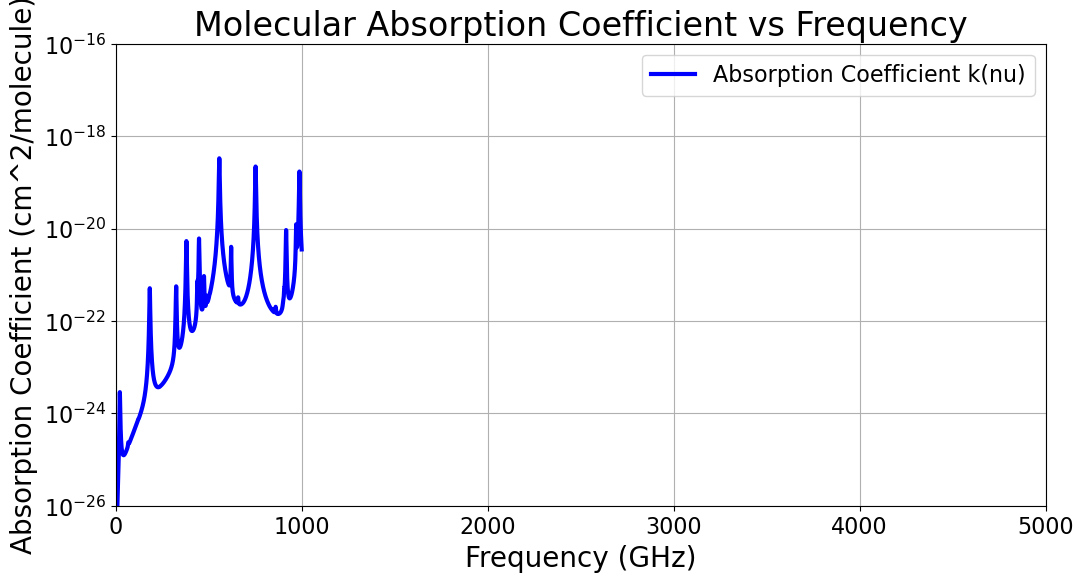

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Update global parameters for presentation visibility
plt.rcParams.update({
    'font.size': 18,              # General font size for text
    'axes.labelsize': 20,         # Size of X and Y axis labels
    'axes.titlesize': 24,         # Size of the graph title
    'xtick.labelsize': 16,        # Size of the numbers on the X axis
    'ytick.labelsize': 16,        # Size of the numbers on the Y axis
    'legend.fontsize': 16,        # Size of the legend text
    'lines.linewidth': 3,       # Thicker lines for the plotted data
})
#Let's plot the absorption coefficient k(nu) vs frequency
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, k_nu, label='Absorption Coefficient k(nu)', color='blue')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Absorption Coefficient (cm^2/molecule)')
plt.title('Molecular Absorption Coefficient vs Frequency')
plt.xlim(0, 5000)  # Limit x-axis to the range of frequencies
plt.ylim(1e-26, 1e-16)
#plt.axhline(y=5e-22, color='red', linestyle='dashed', label='Reference Level (1e-21 cm^2/molecule)')
plt.yscale('log')  # Use logarithmic scale for better visibility of variations
#plt.ylim(0, np.max(k_nu)*1.1)  # Limit y-axis to a bit above the max value for better visualization
plt.grid()
plt.legend()
plt.show()

comparison with pycraf

In [14]:
import jax.numpy as jnp

# ==============================================================================
# ITU-R P.676 Table 1: Oxygen Spectroscopic Data
# ==============================================================================
O2_f0 = jnp.array([50.474214, 50.987745, 51.50336, 52.021429, 52.542418, 53.066934, 53.595775, 54.130025, 54.67118, 55.221384, 55.783815, 56.264774, 56.363399, 56.968211, 57.612486, 58.323877, 58.446588, 59.164204, 59.590983, 60.306056, 60.434778, 61.150562, 61.800158, 62.41122, 62.486253, 62.997984, 63.568526, 64.127775, 64.67891, 65.224078, 65.764779, 66.302096, 66.836834, 67.369601, 67.900868, 68.431006, 68.960312, 118.750334, 368.498246, 424.76302, 487.249273, 715.392902, 773.83949, 834.145546])
O2_a1 = jnp.array([0.975, 2.529, 6.193, 14.32, 31.24, 64.29, 124.6, 227.3, 389.7, 627.1, 945.3, 543.4, 1331.8, 1746.6, 2120.1, 2363.7, 1442.1, 2379.9, 2090.7, 2103.4, 2438.0, 2479.5, 2275.9, 1915.4, 1503.0, 1490.2, 1078.0, 728.7, 461.3, 274.0, 153.0, 80.4, 39.8, 18.56, 8.172, 3.397, 1.334, 940.3, 67.4, 637.7, 237.4, 98.1, 572.3, 183.1])
O2_a2 = jnp.array([9.651, 8.653, 7.709, 6.819, 5.983, 5.201, 4.474, 3.8, 3.182, 2.618, 2.109, 0.014, 1.654, 1.255, 0.91, 0.621, 0.083, 0.387, 0.207, 0.207, 0.386, 0.621, 0.91, 1.255, 0.083, 1.654, 2.108, 2.617, 3.181, 3.8, 4.473, 5.2, 5.982, 6.818, 7.708, 8.652, 9.65, 0.01, 0.048, 0.044, 0.049, 0.145, 0.141, 0.145])
O2_a3 = jnp.array([6.69, 7.17, 7.64, 8.11, 8.58, 9.06, 9.55, 9.96, 10.37, 10.89, 11.34, 17.03, 11.89, 12.23, 12.62, 12.95, 14.91, 13.53, 14.08, 14.15, 13.39, 12.92, 12.63, 12.17, 15.13, 11.74, 11.34, 10.88, 10.38, 9.96, 9.55, 9.06, 8.58, 8.11, 7.64, 7.17, 6.69, 16.64, 16.4, 16.4, 16.0, 16.0, 16.2, 14.7])
O2_a4 = jnp.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a5 = jnp.array([2.566, 2.246, 1.947, 1.667, 1.388, 1.349, 2.227, 3.17, 3.558, 2.56, -1.172, 3.525, -2.378, -3.545, -5.416, -1.932, 6.768, -6.561, 6.957, -6.395, 6.342, 1.014, 5.014, 3.029, -4.499, 1.856, 0.658, -3.036, -3.968, -3.528, -2.548, -1.66, -1.68, -1.956, -2.216, -2.492, -2.773, -0.439, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
O2_a6 = jnp.array([6.85, 6.8, 6.729, 6.64, 6.526, 6.206, 5.085, 3.75, 2.654, 2.952, 6.135, -0.978, 6.547, 6.451, 6.056, 0.436, -1.273, 2.309, -0.776, 0.699, -2.825, -0.584, -6.619, -6.759, 0.844, -6.675, -6.139, -2.895, -2.59, -3.68, -5.002, -6.091, -6.393, -6.475, -6.545, -6.6, -6.65, 0.079, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

O2_DATA = {
    'f0': O2_f0, 'a1': O2_a1, 'a2': O2_a2, 
    'a3': O2_a3, 'a4': O2_a4, 'a5': O2_a5, 'a6': O2_a6
}

# ==============================================================================
# ITU-R P.676 Table 2: Water Vapor Spectroscopic Data
# ==============================================================================
H2O_f0 = jnp.array([22.23508, 67.80396, 119.99594, 183.310091, 321.225644, 325.152919, 336.222601, 380.197372, 390.134508, 437.346667, 439.150812, 443.018295, 448.001075, 470.888947, 474.689127, 488.491133, 503.568532, 504.482692, 547.67644, 552.02096, 556.936002, 620.700807, 645.866155, 658.00528, 752.033227, 841.053973, 859.962313, 899.306675, 902.616173, 906.207325, 916.171582, 923.118427, 970.315022, 987.926764, 1780.0])
H2O_b1 = jnp.array([0.113, 0.0012, 0.0008, 2.42, 0.0483, 1.499, 0.0011, 11.52, 0.0046, 0.065, 0.9218, 0.1976, 10.32, 0.3297, 1.262, 0.252, 0.039, 0.013, 9.701, 14.77, 487.4, 5.012, 0.0713, 0.3022, 239.6, 0.014, 0.1472, 0.0605, 0.0426, 0.1876, 8.34, 0.0869, 8.972, 132.1, 22300.0])
H2O_b2 = jnp.array([2.143, 8.735, 8.356, 0.668, 6.181, 1.54, 9.829, 1.048, 7.35, 5.05, 3.596, 5.05, 1.405, 3.599, 2.381, 2.853, 6.733, 6.733, 0.114, 0.114, 0.159, 2.2, 8.58, 7.82, 0.396, 8.18, 7.989, 7.917, 8.432, 5.111, 1.442, 10.22, 1.92, 0.258, 0.952])
H2O_b3 = jnp.array([28.11, 28.58, 29.48, 30.5, 23.03, 27.83, 26.93, 28.73, 21.52, 18.45, 21.0, 18.6, 26.32, 21.52, 23.55, 26.02, 16.12, 16.12, 26.0, 26.0, 32.1, 24.38, 18.0, 32.1, 30.6, 15.9, 30.6, 29.85, 28.65, 24.08, 26.7, 29.0, 25.5, 29.85, 176.2])
H2O_b4 = jnp.array([0.69, 0.69, 0.7, 0.64, 0.67, 0.68, 0.69, 0.54, 0.63, 0.6, 0.63, 0.6, 0.66, 0.66, 0.65, 0.69, 0.61, 0.61, 0.7, 0.7, 0.69, 0.71, 0.6, 0.69, 0.68, 0.33, 0.68, 0.68, 0.7, 0.7, 0.7, 0.7, 0.64, 0.68, 0.5])
H2O_b5 = jnp.array([4.8, 4.93, 4.78, 5.3, 4.69, 4.85, 4.74, 5.38, 4.81, 4.23, 4.29, 4.23, 4.84, 4.57, 4.65, 5.04, 3.98, 4.01, 4.5, 4.5, 4.11, 4.68, 4.0, 4.14, 4.09, 5.76, 4.09, 4.53, 5.1, 4.7, 4.78, 5.0, 4.94, 4.55, 30.5])
H2O_b6 = jnp.array([1.0, 0.82, 0.79, 0.85, 0.54, 0.74, 0.61, 0.89, 0.55, 0.48, 0.52, 0.5, 0.67, 0.65, 0.64, 0.72, 0.43, 0.45, 1.0, 1.0, 1.0, 0.68, 0.5, 1.0, 0.84, 0.45, 0.84, 0.9, 0.95, 0.53, 0.78, 0.8, 0.67, 0.9, 5.0])

H2O_DATA = {
    'f0': H2O_f0, 'b1': H2O_b1, 'b2': H2O_b2, 
    'b3': H2O_b3, 'b4': H2O_b4, 'b5': H2O_b5, 'b6': H2O_b6
}




import jax
import jax.numpy as jnp
from functools import partial

# Import the pre-loaded ITU constants we generated from the CSVs
#from .itu_constants import O2_DATA, H2O_DATA

# ==============================================================================
# 1. Point-wise Physics Core (ITU-R P.676-13 Annex 1)
# ==============================================================================

def compute_attenuation_point(T, P, e, freqs_GHz, o2_data, h2o_data):
    """
    Computes the specific attenuation for a single spatial point over multiple frequencies.
    Input scalars: T (Kelvin), P (hPa, dry air pressure), e (hPa, water vapor pressure).
    Input vector: freqs_GHz (shape: Nf,)
    Returns: gamma_dry, gamma_wet (both shape: Nf,)
    """
    # Expand freqs for matrix broadcasting against spectral lines
    # f shape: (Nf, 1)
    f = freqs_GHz[:, None] 
    
    # Temperature parameter
    theta = 300.0 / T
    
    # --- Oxygen Calculation ---
    f_o2 = o2_data['f0'][None, :] # Shape: (1, N_o2_lines), frequency of each oxygen line
    
    # Line strength
    S_o2 = o2_data['a1'] * 1e-7 * P * (theta**3) * jnp.exp(o2_data['a2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Zeeman broadening
    df_o2 = o2_data['a3'] * 1e-4 * (P * (theta**(0.8 - o2_data['a4'])) + 1.1 * e * theta) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_o2 = jnp.sqrt(df_o2**2 + 2.25e-6) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Interference factor
    delta_o2 = (o2_data['a5'] + o2_data['a6'] * theta) * 1e-4 * (P + e) * (theta**0.8) # Eq (7) from ITU-R P.676-13 Annex 1
    
    # Line shape (Van Vleck-Weisskopf)
    num1 = df_o2 - delta_o2 * (f_o2 - f)
    den1 = (f_o2 - f)**2 + df_o2**2
    num2 = df_o2 - delta_o2 * (f_o2 + f)
    den2 = (f_o2 + f)**2 + df_o2**2
    F_o2 = (f / f_o2) * ((num1 / den1) + (num2 / den2)) # Eq (5) from ITU-R P.676-13 Annex 1
    
    # Sum over all lines (axis 1 collapses the lines, leaving shape Nf)
    N_pp_o2_lines = jnp.sum(S_o2 * F_o2, axis=1) # You sum over the lines
    
    # Dry Continuum (Debye spectrum + nitrogen attenuation)
    d = 5.6e-4 * (P + e) * (theta**0.8) #eq (9) from ITU-R P.676-13 Annex 1
    term1 = 6.14e-5 / (d * (1 + (freqs_GHz / d)**2))
    term2 = (1.4e-12 * P * (theta**1.5)) / (1 + 1.9e-5 * (freqs_GHz**1.5))
    N_pp_D = freqs_GHz * P * (theta**2) * (term1 + term2) # Eq (8) from ITU-R P.676-13 Annex 1
    
    gamma_dry = 0.1820 * freqs_GHz * (N_pp_o2_lines + N_pp_D) # Eq (1) and (2a) from ITU-R P.676-13 Annex 1


    # --- Water Vapor Calculation ---
    f_h2o = h2o_data['f0'][None, :] #frequency of each water vapor line, shape: (1, N_h2o_lines)
    
    # Line strength
    S_h2o = h2o_data['b1'] * 1e-1 * e * (theta**3.5) * jnp.exp(h2o_data['b2'] * (1 - theta)) # Eq (3) from ITU-R P.676-13 Annex 1
    
    # Line width and Doppler broadening
    df_h2o = h2o_data['b3'] * 1e-4 * (P * (theta**h2o_data['b4']) + h2o_data['b5'] * e * (theta**h2o_data['b6'])) # Eq (6a) from ITU-R P.676-13 Annex 1
    df_h2o = 0.535 * df_h2o + jnp.sqrt(0.217 * (df_h2o**2) + (2.1316e-12 * (f_h2o**2)) / theta) # Eq (6b) from ITU-R P.676-13 Annex 1
    
    # Line shape (interference factor delta is 0 for H2O)
    num1_w = df_h2o
    den1_w = (f_h2o - f)**2 + df_h2o**2
    num2_w = df_h2o
    den2_w = (f_h2o + f)**2 + df_h2o**2
    F_h2o = (f / f_h2o) * ((num1_w / den1_w) + (num2_w / den2_w)) # Eq (5) from ITU-R P.676-13 Annex 1, but with delt_H2O=0 for water vapor lines
    
    # Sum over all water vapor lines
    N_pp_h2o = jnp.sum(S_h2o * F_h2o, axis=1)
    
    gamma_wet = 0.1820 * freqs_GHz * N_pp_h2o # Eq (1) and (2b) from ITU-R P.676-13 Annex 1
    
    return gamma_dry, gamma_wet


# ==============================================================================
# 2. 3D Spatial Vectorization (Direct 4D Output)
# ==============================================================================

# Stack jax.vmap three times to map over the Z, Y, and X axes of your 3D cubes.
# The 'None' arguments ensure the frequencies and spectroscopic dicts aren't mapped over.
compute_1d = jax.vmap(compute_attenuation_point, in_axes=(0, 0, 0, None, None, None))
compute_2d = jax.vmap(compute_1d, in_axes=(0, 0, 0, None, None, None))
compute_3d = jax.vmap(compute_2d, in_axes=(0, 0, 0, None, None, None))

@partial(jax.jit, static_argnames=['o2_data', 'h2o_data'])
def compute_3d_attenuation(T_grid, P_grid, e_grid, freqs_GHz, o2_data=O2_DATA, h2o_data=H2O_DATA):
    """
    Computes specific attenuation over a full 3D grid simultaneously.
    
    Input grids: T_grid, P_grid, e_grid of shape (Nx, Ny, Nz)
    Input freq: freqs_GHz of shape (Nf,)
    Returns: gamma_dry, gamma_wet of shape (Nx, Ny, Nz, Nf)
    """
    return compute_3d(T_grid, P_grid, e_grid, freqs_GHz, o2_data, h2o_data)

In [15]:
gamma_wet = compute_attenuation_point(T, P, P_water, frequencies/1e9, O2_DATA, H2O_DATA)[1]

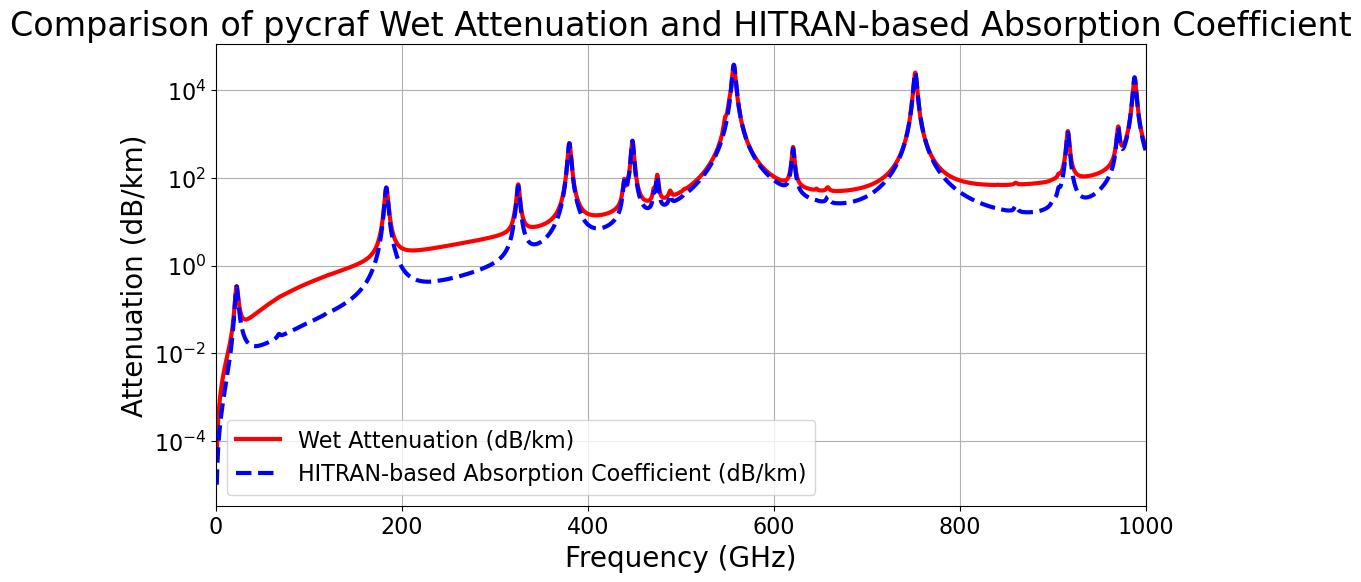

In [16]:
#Let's compare the spectrum of gamma_wet to the original k_nu we computed from the HITRAN-based function gamma_dB_km
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, gamma_wet, label='Wet Attenuation (dB/km)', color='red')
plt.plot(frequencies * 1e-9, gamma_lines_dB_km, label='HITRAN-based Absorption Coefficient (dB/km)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of pycraf Wet Attenuation and HITRAN-based Absorption Coefficient')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

Let's try to import the H2O continuum

In [17]:
import re
import numpy as np

def list_c_arrays(filepath):
    """Scans a C file and returns the names of all hardcoded double arrays."""
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Look for patterns like: double my_array[] = {
    pattern = r"double\s+([a-zA-Z0-9_]+)(?:\[.*?\])?\s*=\s*\{"
    return re.findall(pattern, content)

# Point this to your extracted src directory
h2o_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/h2o_continuum.c'
mt_ckd_file = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/mt_ckd.c'

print("Arrays in h2o_continuum.c:", list_c_arrays(h2o_file))
print("Arrays in mt_ckd.c:", list_c_arrays(mt_ckd_file))

Arrays in h2o_continuum.c: []
Arrays in mt_ckd.c: ['mt_ckd_for_absco_ref', 'mt_ckd_self_absco_ref', 'mt_ckd_self_texp', 'mt_ckd_wavenumbers']


In [18]:
def extract_c_array(filepath, array_name):
    """Extracts the numbers from a specific C array into a NumPy array."""
    with open(filepath, 'r') as f:
        content = f.read()
        
    # Match the specific array and grab everything between the curly braces
    pattern = rf"double\s+{array_name}(?:\[.*?\])?\s*=\s*\{{([^}}]+)\}}"
    match = re.search(pattern, content, re.DOTALL)
    
    if not match:
        raise ValueError(f"Could not find array '{array_name}' in the file.")
        
    raw_numbers = match.group(1)
    # Find all valid floating-point numbers (handles negatives and scientific notation)
    number_strings = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", raw_numbers)
    
    return np.array(number_strings, dtype=float)

# The path to your mt_ckd.c file
c_file_path = '/pscratch/sd/v/valer/atmo3/notebooks/implementation_am_code/am-13.0/src/mt_ckd.c'

# Extract the arrays using the names you just discovered!
nu_grid_cm  = extract_c_array(c_file_path, 'mt_ckd_wavenumbers')
Cs_296      = extract_c_array(c_file_path, 'mt_ckd_self_absco_ref')
Cf_296      = extract_c_array(c_file_path, 'mt_ckd_for_absco_ref')
T_exp       = extract_c_array(c_file_path, 'mt_ckd_self_texp')

print(f"Extracted {len(nu_grid_cm)} data points for the continuum grid.")

Extracted 53 data points for the continuum grid.


In [19]:
print(nu_grid_cm)

[  0.  10.  20.  30.  40.  50.  60.  70.  80.  90. 100. 110. 120. 130.
 140. 150. 160. 170. 180. 190. 200. 210. 220. 230. 240. 250. 260. 270.
 280. 290. 300. 310. 320. 330. 340. 350. 360. 370. 380. 390. 400. 410.
 420. 430. 440. 450. 460. 470. 480. 490. 500. 510. 520.]


In [20]:
import numpy as np

def compute_k_cm5(freq_GHz, T, nu_ckd, C_s_296, C_f_296, T_exp):
    """
    Computes the MT_CKD self and air continuum coefficients in cm^5.
    
    Inputs:
    freq_GHz  : Array of frequencies to evaluate [GHz]
    T         : Ambient temperature [K]
    nu_ckd    : MT_CKD Wavenumber grid [cm^-1]
    C_s_296   : MT_CKD Self-broadening reference table
    C_f_296   : MT_CKD Foreign-broadening reference table
    T_exp     : MT_CKD Self-broadening temperature exponent table
    
    Returns:
    k_self_cm5, k_air_cm5
    """
    c2 = 1.4387770  # Second radiation constant [cm*K]
    # Reference density at 1 atm and 296K
    n_ref = 2.479e19  
    nu_cm = freq_GHz / 29.9792458
    
    # 1. Interpolate the MT_CKD tables to our frequency grid
    Cs_296_interp = np.interp(nu_cm, nu_ckd, C_s_296)
    Cf_296_interp = np.interp(nu_cm, nu_ckd, C_f_296)
    Texp_interp   = np.interp(nu_cm, nu_ckd, T_exp)
    
    # 2. Apply Temperature Scaling
    # Self continuum exponential scaling
    Cs_T = Cs_296_interp * np.exp(Texp_interp * ((1.0 / T) - (1.0 / 296.0)))
    
    # Foreign continuum (independent of T in base MT_CKD)
    Cf_T = Cf_296_interp
    
    # 3. Compute Detailed Balance Radiation Term
    rad_term = nu_cm * np.tanh((c2 * nu_cm) / (2.0 * T))
    
    # 4. Final coefficients in cm^5
    # Divide out the MT_CKD atmospheric scaling to get true binary cm^5
    k_self_cm5 = (rad_term * Cs_T) / n_ref
    k_air_cm5  = (rad_term * Cf_T) / n_ref
    
    return k_self_cm5, k_air_cm5




In [21]:
k_self_cm5, k_air_cm5 = compute_k_cm5(frequencies/1e9, T, nu_grid_cm, Cs_296, Cf_296, T_exp)

# 2. Calculate the local molecular number density [molecules / cm^3]
# Ideal gas law: n = P / (k_B * T)
n_water_density = P_water *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

n_air_density = (P - P_water) *100 / (constants.k * T) * 1e-6 # Convert from hPa to atm and from m^3 to cm^3

# 3. Convert to Specific Attenuation [dB/km]
# alpha [Np/cm] = n_water_density * k_nu
# 10^5 converts cm to km, 4.3429 converts Nepers to Decibels
gamma_dB_km_self = n_water_density**2 * k_self_cm5 * 1e5 * 4.3429
gamma_dB_km_air = n_air_density* n_water_density * k_air_cm5 * 1e5 * 4.3429

In [ ]:
k_self_cm5_logT, k_air_cm5_logT = compute_k_cm5_mtckd_logT(frequencies/1e9, T, nu_grid_cm, Cs_296, Cs_260, Cf_296)

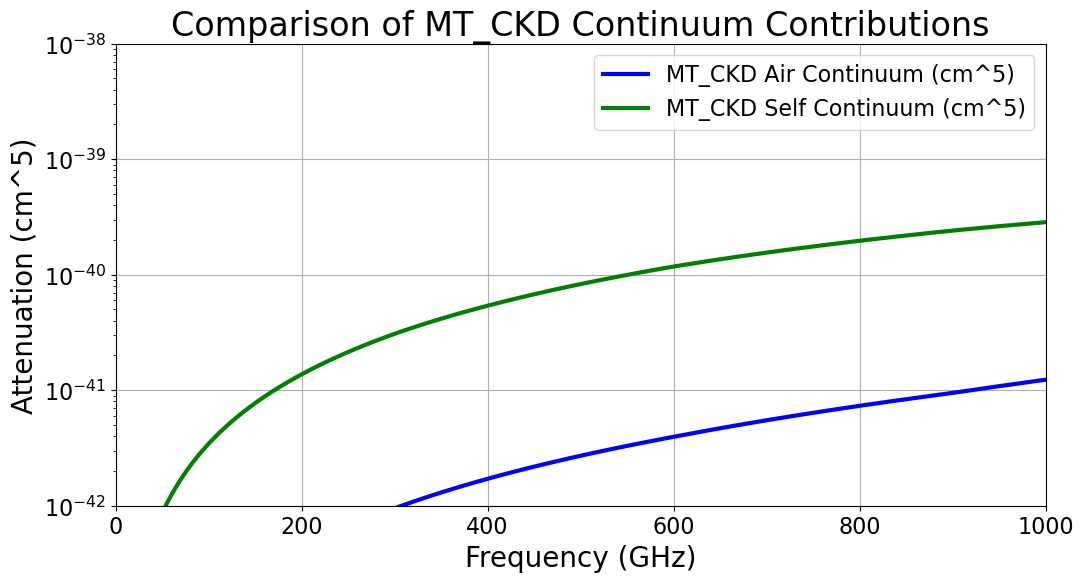

In [22]:
# Let's plot the k_self and k_air contributions separately
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, k_air_cm5, label='MT_CKD Air Continuum (cm^5)', color='blue')
plt.plot(frequencies * 1e-9, k_self_cm5, label='MT_CKD Self Continuum (cm^5)', color='green')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (cm^5)')
plt.title('Comparison of MT_CKD Continuum Contributions')
plt.xlim(0, 1000)
plt.ylim(1e-42, 1e-38)
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

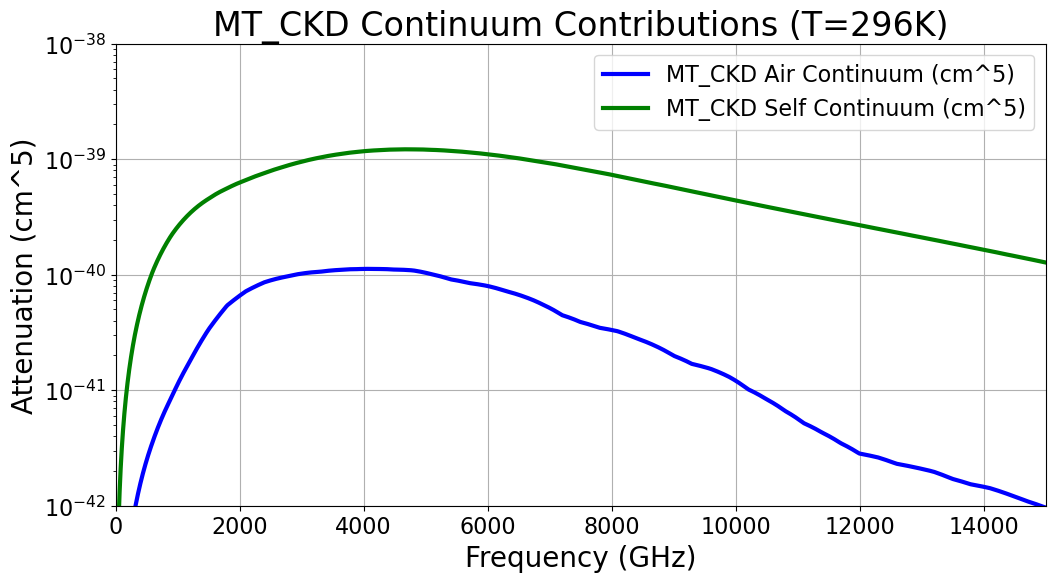

In [23]:
frequencies_GHz_continuum = np.arange(1, 15000, 1)  # 1 GHz to 15 THz with 1 GHz steps
k_self_cm5_cont, k_air_cm5_cont = compute_k_cm5(frequencies_GHz_continuum, 296, nu_grid_cm, Cs_296, Cf_296, T_exp)

plt.figure(figsize=(12, 6))
plt.plot(frequencies_GHz_continuum , k_air_cm5_cont, label='MT_CKD Air Continuum (cm^5)', color='blue')
plt.plot(frequencies_GHz_continuum , k_self_cm5_cont, label='MT_CKD Self Continuum (cm^5)', color='green')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (cm^5)')
plt.title('MT_CKD Continuum Contributions (T=296K)')
plt.xlim(0, 15000)
plt.ylim(1e-42, 1e-38)
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

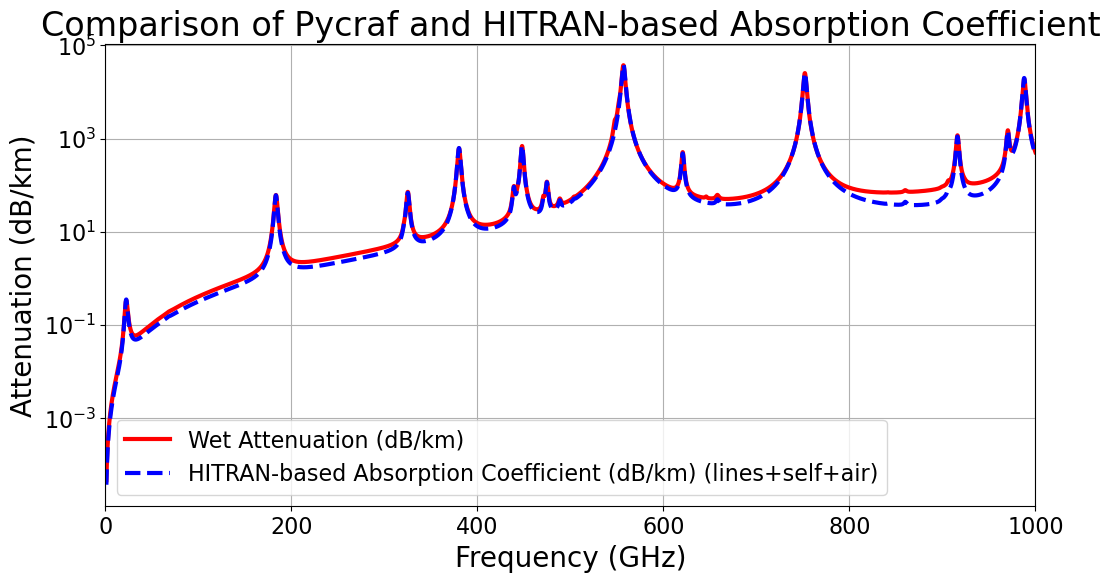

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, gamma_wet, label='Wet Attenuation (dB/km)', color='red')
plt.plot(frequencies * 1e-9, gamma_lines_dB_km + gamma_dB_km_air + gamma_dB_km_self, label='HITRAN-based Absorption Coefficient (dB/km) (lines+self+air)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of Pycraf and HITRAN-based Absorption Coefficient')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

/tmp/ipykernel_1199879/282427713.py:2: RuntimeWarning: overflow encountered in exp
  plt.plot(frequencies * 1e-9, (np.exp(gamma_wet) - np.exp(gamma_lines_dB_km +gamma_dB_km_air+gamma_dB_km_self))/np.exp(gamma_wet) * 100, label='Wet Attenuation difference between Pycraf and HITRAN-based (%)', color='red')
/tmp/ipykernel_1199879/282427713.py:2: RuntimeWarning: invalid value encountered in subtract
  plt.plot(frequencies * 1e-9, (np.exp(gamma_wet) - np.exp(gamma_lines_dB_km +gamma_dB_km_air+gamma_dB_km_self))/np.exp(gamma_wet) * 100, label='Wet Attenuation difference between Pycraf and HITRAN-based (%)', color='red')
/tmp/ipykernel_1199879/282427713.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(frequencies * 1e-9, (np.exp(gamma_wet) - np.exp(gamma_lines_dB_km +gamma_dB_km_air+gamma_dB_km_self))/np.exp(gamma_wet) * 100, label='Wet Attenuation difference between Pycraf and HITRAN-based (%)', color='red')


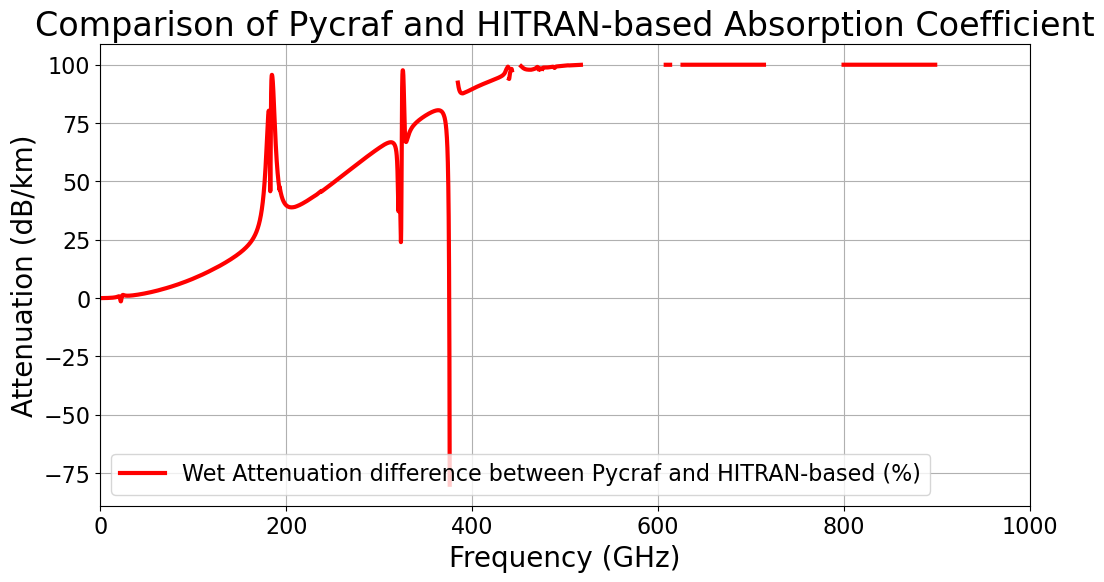

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, (np.exp(gamma_wet) - np.exp(gamma_lines_dB_km +gamma_dB_km_air+gamma_dB_km_self))/np.exp(gamma_wet) * 100, label='Wet Attenuation difference between Pycraf and HITRAN-based (%)', color='red')
#plt.plot(frequencies * 1e-9, gamma_lines_dB_km + gamma_dB_km_air + gamma_dB_km_self, label='HITRAN-based Absorption Coefficient (dB/km) (lines+self+air)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of Pycraf and HITRAN-based Absorption Coefficient')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
#plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

In [26]:
# Let's find the L value to get PWV of 1mm with the given P_water and T
# Let's transform into rho_water in kg/m^3
R_H2O = 461.5 # Specific gas constant for water vapor in J/(kg*K)

rho_water = P_water *100 / (R_H2O * T) # in kg/m^3
# PWV in kg/m^2 is rho_water * L (where L is the path length in meters)
L = 1/rho_water # in meters, to get 1 kg/m^2 which is equivalent to 1 mm of PWV
print(L)

#So, let's see the optical depth at 1mm of PWV for the wet attenuation

tau_wet_1mm_pycraf = gamma_wet/ 4.3429 * L * 1e-3 # Convert from dB/km to Np/m and multiply by path length in meters

tau_wet_1mm_am = (gamma_lines_dB_km + gamma_dB_km_air + gamma_dB_km_self)/ 4.3429 * L * 1e-3 # Convert from dB/km to Np/m and multiply by path length in meters


124.605


In [27]:
T_b_pycraf = T * (1 - np.exp(-tau_wet_1mm_pycraf))
T_b_am = T * (1 - np.exp(-tau_wet_1mm_am))

print("Brightness temperature at 1mm PWV (Pycraf):", T_b_pycraf)
print("Brightness temperature at 1mm PWV (AM):", T_b_am)

Brightness temperature at 1mm PWV (Pycraf): [3.5405159e-04 4.3451786e-04 4.9889088e-04 ... 2.6999991e+02 2.6999991e+02
 2.6999988e+02]
Brightness temperature at 1mm PWV (AM): [2.81455293e-04 3.40620470e-04 4.05459739e-04 ... 2.69999374e+02
 2.69999241e+02 2.69999085e+02]


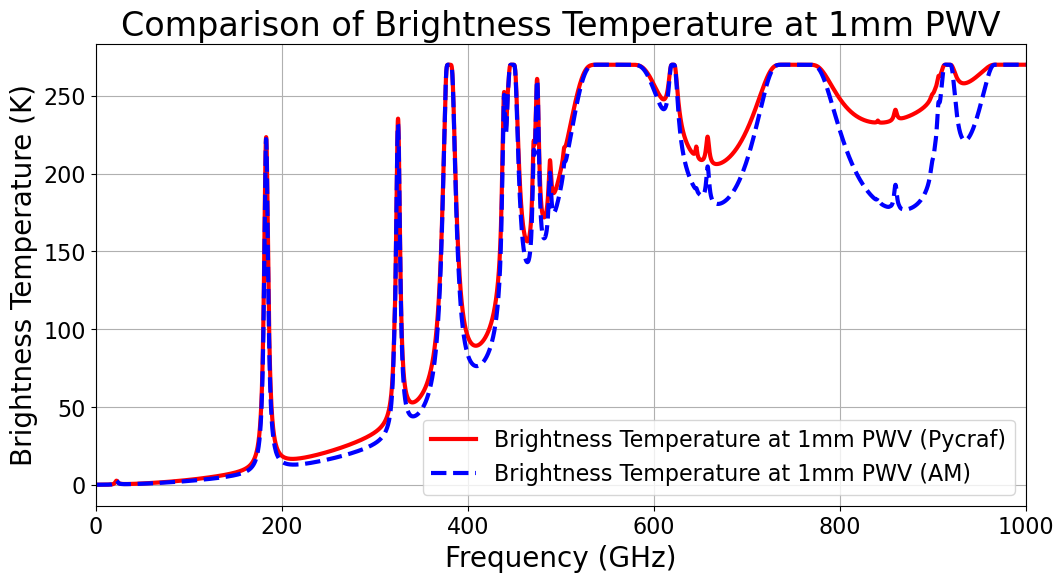

In [28]:
#Let's compare the brightness temperatures
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, T_b_pycraf, label='Brightness Temperature at 1mm PWV (Pycraf)', color='red')
plt.plot(frequencies * 1e-9, T_b_am, label='Brightness Temperature at 1mm PWV (AM)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Comparison of Brightness Temperature at 1mm PWV')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
#plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

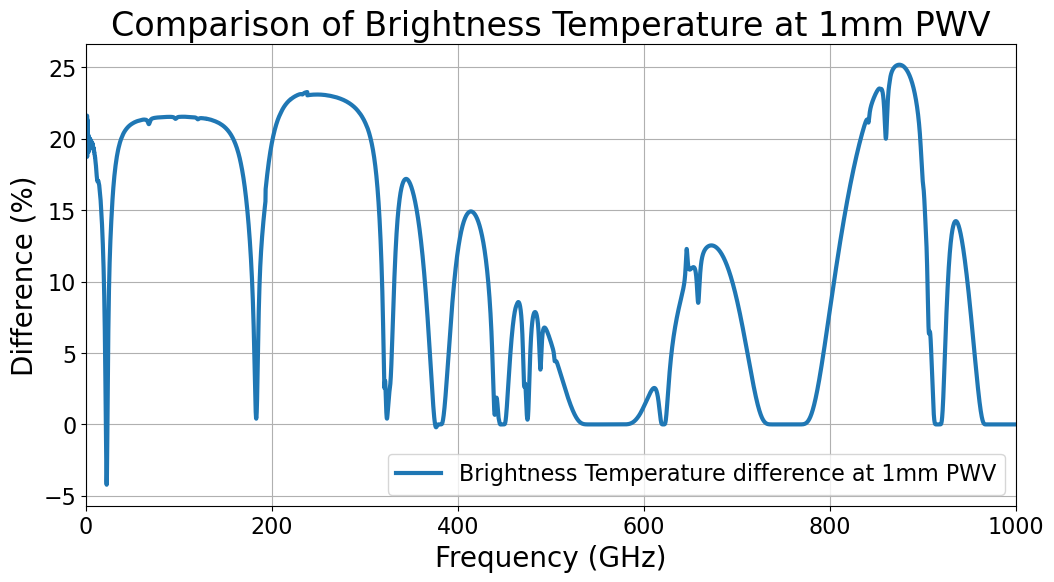

In [29]:
#Let's plot the difference in brightness temperature in percentage
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, (T_b_pycraf - T_b_am)/T_b_pycraf * 100, label='Brightness Temperature difference at 1mm PWV')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Difference (%)')
plt.title('Comparison of Brightness Temperature at 1mm PWV')
plt.xlim(0, 1000)
plt.grid()
plt.legend()
plt.show()

Let's now compare with PyRTlib

In [30]:
from pyrtlib.tb_spectrum import TbCloudRTE
from pyrtlib.climatology import AtmosphericProfiles as atmp
from pyrtlib.utils import ppmv2gkg, mr2rh, _dcerror, constants
from pyrtlib.absorption_model import H2OAbsModel, O2AbsModel, N2AbsModel

# ==============================================================================
# REMPLACEMENT INTÉGRAL DE LA MÉTHODE H2O POUR CORRIGER LE BUG INTERNE (df[j])
# ==============================================================================
def fixed_h2o_absorption(self, pdrykpa, vx, ekpa, frq, amu=None):
    if amu:
        if H2OAbsModel.model > 'R17':
            self.h2oll.cf = amu['con_Cf'].value
            self.h2oll.cs = amu['con_Cs'].value
        else:
            self.h2oll.cf = amu['con_Cf'].value * amu['con_Cf_factr'].value
            self.h2oll.cs = amu['con_Cs'].value * amu['con_Cs_factr'].value
        self.h2oll.xcf = amu['con_Xf'].value
        self.h2oll.xcs = amu['con_Xs'].value
        self.h2oll.s1 = amu['S'].value
        self.h2oll.b2 = amu['B2'].value
        self.h2oll.w0 = amu['gamma_a'].value / 1000.0
        self.h2oll.w0s = amu['gamma_w'].value / 1000.0
        self.h2oll.x = amu['n_a'].value
        self.h2oll.xs = amu['n_w'].value
        if H2OAbsModel.model > 'R17':
            self.h2oll.sh = amu['delta_a'].value / 1000.0
            self.h2oll.shs = amu['delta_w'].value / 1000.0
            self.h2oll.xh = amu['n_da'].value
            self.h2oll.xhs = amu['n_dw'].value
        else:
            self.h2oll.sr = amu['SR'].value
        self.h2oll.fl = amu['FL'].value

    db2np = np.log(10.0) * 0.1
    rvap = (0.01 * 8.31451) / 18.01528
    factor = 0.182 * frq
    t = 300.0 / vx
    p = (pdrykpa + ekpa) * 10.0
    rho = ekpa * 10.0 / (rvap * t)
    f = frq

    if rho.any() <= 0.0:
        return 0, 0

    pvap = (rho * t) / 216.68
    if H2OAbsModel.model in ['R03', 'R16', 'R17', 'R98']:
        pvap = (rho * t) / 217.0
    if H2OAbsModel.model in ['R22SD', 'R23SD', 'R24', 'MWL24']:
        pvap = (constants("Rwatvap")[0] * 1e-05) * rho * t
    pda = p - pvap
    if H2OAbsModel.model in ['R03', 'R16', 'R98']:
        den = 3.335e+16 * rho
    else:
        den = 3.344e+16 * rho

    ti = self.h2oll.reftcon / t
    if H2OAbsModel.model in ['R03', 'R98']:
        con = (5.43e-10 * pda * ti ** 3 + 1.8e-08 * pvap * ti ** 7.5) * pvap * f * f
    elif H2OAbsModel.model == 'MWL24':
        con_self = self.h2o_continuum_mwl24(f, vx) * pvap * pvap
        con_frgn = 7.1e-10 * (300./t)**4.4 * f**1.96 * pda * pvap
        con = con_self + con_frgn
    else:
        con = (self.h2oll.cf * pda * ti ** self.h2oll.xcf + self.h2oll.cs * pvap * ti ** self.h2oll.xcs) * pvap * f * f

    nlines = len(self.h2oll.fl)
    ti = self.h2oll.reftline / t
    
    # === LE CORRECTIF CRUCIAL EST ICI ===
    df = np.zeros(2) # Remplacement de np.zeros((2,1)) pour éviter les array 2D
    # ====================================

    if H2OAbsModel.model.startswith(('R19SD', 'R20SD', 'R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24')):
        tiln = np.log(ti)
        ti2 = np.exp(2.5 * tiln)
        summ = 0.0
        if H2OAbsModel.model in ['R23SD', 'R24']:
            if self.h2oll.cs > 0:
                con = self.h2oll.cs * ti * self.h2oll.xcs
                npp_cs = con
            else:
                npp_cs = self.h2o_continuum(frq, vx, 1)
        for i in range(0, nlines):
            width0 = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i] + self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width2 = self.h2oll.w2[i] * pda + self.h2oll.w2s[i] * pvap
            if H2OAbsModel.model in ['R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24']:
                if self.h2oll.w2[i] > 0:
                    width2 = self.h2oll.w2[i] * pda * ti ** self.h2oll.xw2[i] + self.h2oll.w2s[i] * pvap * ti ** self.h2oll.xw2s[i]
                else:
                    width2 = 0
            shiftf = self.h2oll.sh[i] * pda * (1. - self.h2oll.aair[i] * tiln) * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * (1. - self.h2oll.aself[i] * tiln) * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width0 ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width0 / (562500.0 + wsq)
            if H2OAbsModel.model in ["R21SD", 'R22SD', 'R23SD', 'R24', 'MWL24']:
                delta2 = self.h2oll.d2[i] * pda + self.h2oll.d2s[i] * pvap
            res = 0.0
            for j in range(0, 2):
                if width2 > 0 and j == 0 and np.abs(df[j]) < (10 * width0):
                    xc = complex((width0 - np.dot(1.5, width2)), df[j]) / width2
                    if H2OAbsModel.model == 'R20SD':
                        if i == 1:
                            delta2 = (self.h2oll.d2air * pda) + (self.h2oll.d2self * pvap)
                        else:
                            delta2 = 0.0
                        xc = complex((width0 - np.dot(1.5, width2)), df[j] + np.dot(1.5, delta2)) / complex(width2, -delta2)
                    elif H2OAbsModel.model in ["R21SD", 'R22SD', 'R23SD', 'R24', 'MWL24']:
                        xc = complex((width0 - 1.5 * width2), df[j] + 1.5 * delta2) / complex(width2, -delta2)
                    xrt = np.sqrt(xc)
                    pxw = 1.77245385090551603 * xrt * _dcerror(-np.imag(xrt), np.real(xrt))
                    sd = 2.0 * (1.0 - pxw) / (width2 if H2OAbsModel.model not in ['R20SD', 'R21SD', 'R22SD', 'R23SD', 'R24', 'MWL24'] else complex(width2, -delta2))
                    res += np.real(sd) - base
                elif np.abs(df[j]) < 750.0:
                    res += width0 / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model in ['R16', 'R03', 'R17', 'R98']:
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shift = 0.0 if H2OAbsModel.model == 'R98' else self.h2oll.sr[i] * (width if H2OAbsModel.model == 'R03' else widthf)
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1.0 - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) <= 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model in ['R19', 'R20']:
        tiln = np.log(ti)
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shiftf = self.h2oll.sh[i] * pda * (1. - self.h2oll.aair[i] * tiln) * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * (1. - self.h2oll.aself[i] * tiln) * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) < 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2
    elif H2OAbsModel.model == 'R18':
        ti2 = ti ** 2.5
        summ = 0.0
        for i in range(0, nlines):
            widthf = self.h2oll.w0[i] * pda * ti ** self.h2oll.x[i]
            widths = self.h2oll.w0s[i] * pvap * ti ** self.h2oll.xs[i]
            width = widthf + widths
            shiftf = self.h2oll.sh[i] * pda * ti ** self.h2oll.xh[i]
            shifts = self.h2oll.shs[i] * pvap * ti ** self.h2oll.xhs[i]
            shift = shiftf + shifts
            wsq = width ** 2
            s = self.h2oll.s1[i] * ti2 * np.exp(self.h2oll.b2[i] * (1. - ti))
            df[0] = f - self.h2oll.fl[i] - shift
            df[1] = f + self.h2oll.fl[i] + shift
            base = width / (562500.0 + wsq)
            res = 0.0
            for j in range(0, 2):
                if np.abs(df[j]) < 750.0:
                    res += width / (df[j] ** 2 + wsq) - base
            summ += s * res * (f / self.h2oll.fl[i]) ** 2

    if H2OAbsModel.model in ['R23SD', 'R24']:
        conf = self.h2oll.cf * ti**self.h2oll.xcf
        con = (conf * pda + npp_cs * pvap) * pvap * f**2

    h20m = 2.9915075E-23
    if H2OAbsModel.model in ['R22SD', 'R23SD']:
        npp = 1.e-10 * rho * summ / (np.pi * h20m) / db2np / factor
    elif H2OAbsModel.model == 'R24':
        npp = 1.e-10 * (rho/h20m) * (summ/np.pi) / db2np / factor
    else:
        npp = (3.1831e-05 * den * summ / db2np) / factor

    ncpp = (con / db2np) / factor
    return float(np.squeeze(npp)), float(np.squeeze(ncpp))

# On écrase la méthode originale par notre version saine
H2OAbsModel.h2o_absorption = fixed_h2o_absorption
# ==============================================================================

In [31]:
from pyrtlib.rt_equation import RTEquation


# Oxygène
O2AbsModel.model = 'R24'
O2AbsModel.set_ll()

# Vapeur d'eau
H2OAbsModel.model = 'R23SD' 
H2OAbsModel.set_ll()

h2o_model = H2OAbsModel()

N2AbsModel.model = 'R24'
N2AbsModel.set_ll()


# Your inputs
# frequencies = np.array([...]) # in Hz
# P = float, T = float, P_water = float
o3n = 0.0  # Zero out ozone contribution

P_arr = np.array([P])
T_arr = np.array([T])
P_water_arr = np.array([P_water])

alpha_wet_pyrtlib = np.zeros_like(frequencies)
alpha_dry_pyrtlib = np.zeros_like(frequencies)

for j in range(len(frequencies)):
    # 1. Get the 1-element arrays back from PyRTlib
    awet, adry = RTEquation.clearsky_absorption(
        P_arr, T_arr, P_water_arr, frequencies[j] / 1e9, o3n
    )
    
    # 2. Extract the scalar number at index 0 and assign it to your array
    alpha_wet_pyrtlib[j] = awet[0] #in Np/km
    alpha_dry_pyrtlib[j] = adry[0] #in Np/km

# Convert from Np/km to dB/km
gamma_wet_pyrtlib = alpha_wet_pyrtlib * 4.3429
gamma_dry_pyrtlib = alpha_dry_pyrtlib * 4.3429









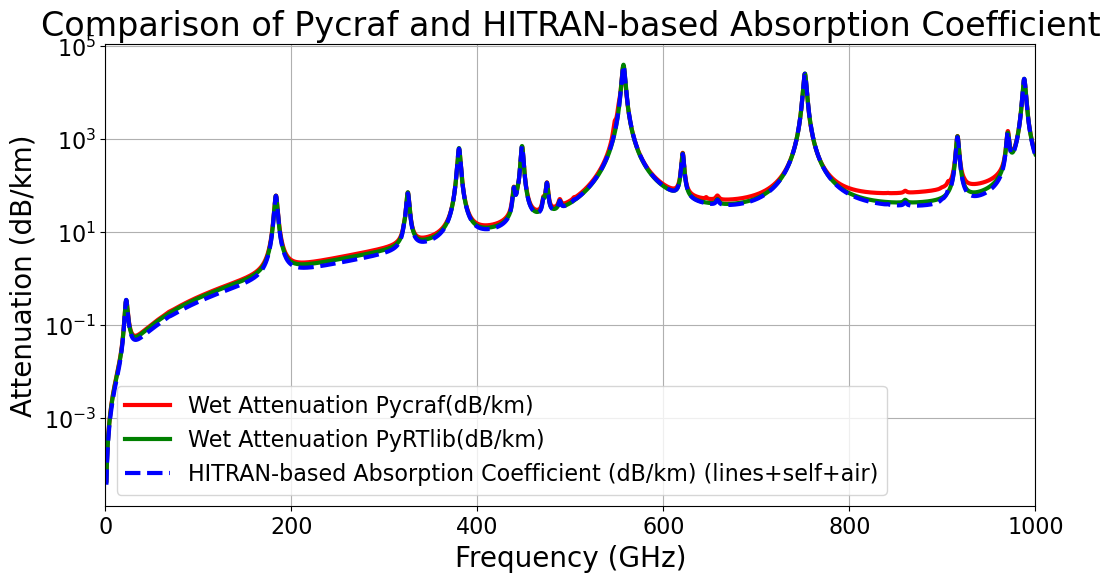

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, gamma_wet, label='Wet Attenuation Pycraf(dB/km)', color='red')
plt.plot(frequencies * 1e-9, gamma_wet_pyrtlib, label='Wet Attenuation PyRTlib(dB/km)', color='green', linestyle='-')
plt.plot(frequencies * 1e-9, gamma_lines_dB_km + gamma_dB_km_air + gamma_dB_km_self, label='HITRAN-based Absorption Coefficient (dB/km) (lines+self+air)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of Pycraf and HITRAN-based Absorption Coefficient')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

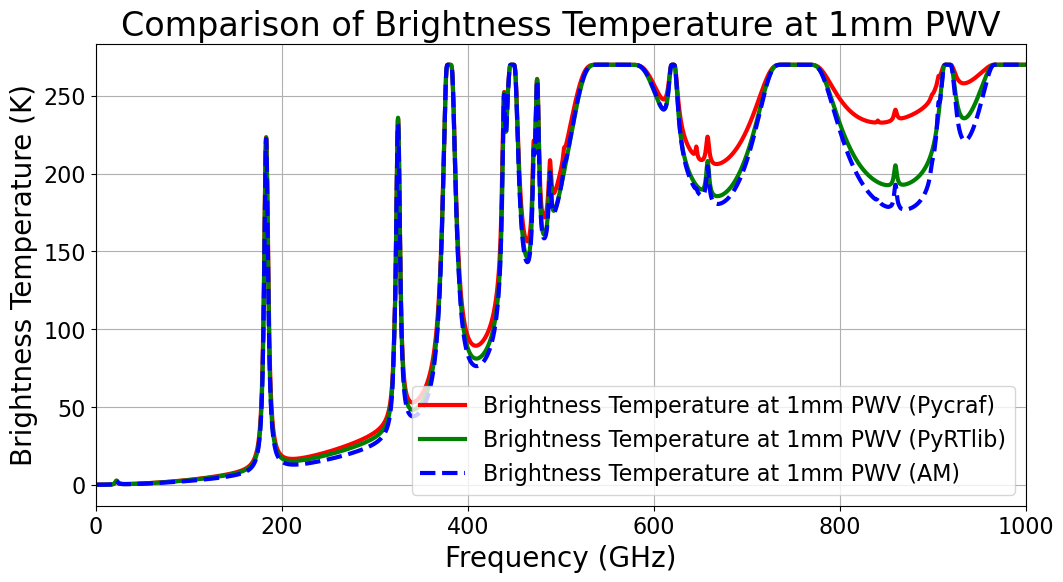

In [33]:
tau_wet_1mm_pyrtlib = gamma_wet_pyrtlib/ 4.3429 * L * 1e-3 # Convert from dB/km to Np/m and multiply by path length in meters
T_b_pyrtlib = T * (1 - np.exp(-tau_wet_1mm_pyrtlib))

plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, T_b_pycraf, label='Brightness Temperature at 1mm PWV (Pycraf)', color='red')
plt.plot(frequencies * 1e-9, T_b_pyrtlib, label='Brightness Temperature at 1mm PWV (PyRTlib)', color='green', linestyle='-')
plt.plot(frequencies * 1e-9, T_b_am, label='Brightness Temperature at 1mm PWV (AM)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Comparison of Brightness Temperature at 1mm PWV')
plt.xlim(0, 1000)  #Limit x-axis to the range of frequencies
#plt.yscale('log')  # Use logarithmic scale for better visibility of variations
plt.grid()
plt.legend()
plt.show()

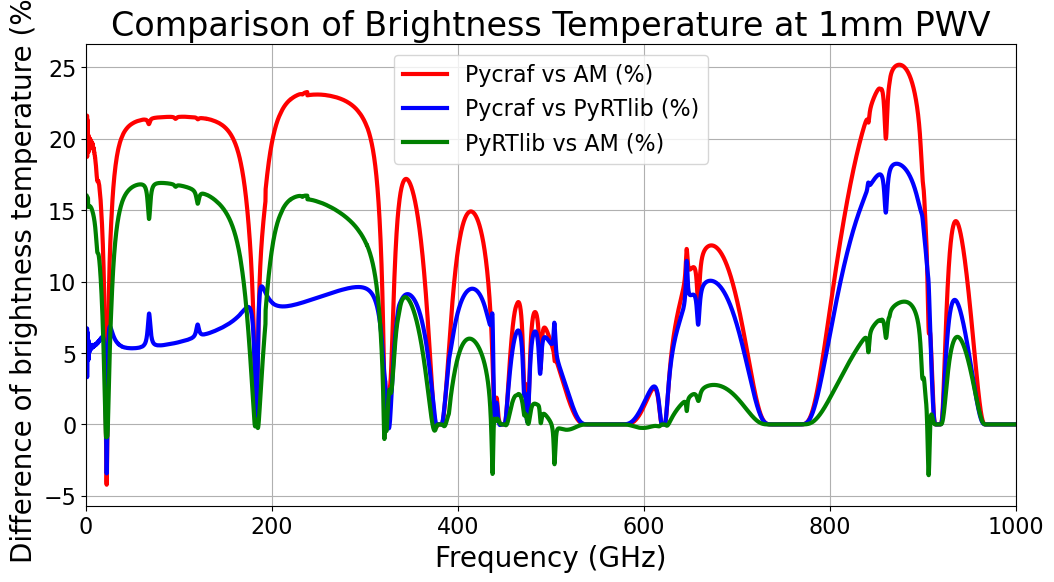

In [34]:
#Let's plot the difference in brightness temperature in percentage for pycraf vs am, pycraf vs pyrtlib, and pyrtlib vs am
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, (T_b_pycraf - T_b_am)/T_b_pycraf * 100, label='Pycraf vs AM (%)', color='red')
plt.plot(frequencies * 1e-9, (T_b_pycraf - T_b_pyrtlib)/T_b_pycraf * 100, label='Pycraf vs PyRTlib (%)', color='blue')
plt.plot(frequencies * 1e-9, (T_b_pyrtlib - T_b_am)/T_b_pyrtlib * 100, label='PyRTlib vs AM (%)', color='green')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Difference of brightness temperature (%)')
plt.title('Comparison of Brightness Temperature at 1mm PWV')
plt.xlim(0, 1000)
plt.grid()
plt.legend()
plt.show()

In [35]:
from pyrtlib.absorption_model import AbsModel

AbsModel.implemented_models()

{'Oxygen': ['R98',
  'R03',
  'R16',
  'R17',
  'R18',
  'R19',
  'R19SD',
  'R20',
  'R20SD',
  'R22',
  'R23',
  'R24'],
 'WaterVapour': ['R98',
  'R03',
  'R16',
  'R17',
  'R18',
  'R19',
  'R19SD',
  'R20',
  'R20SD',
  'R21SD',
  'R22SD',
  'R23SD',
  'R24',
  'MWL24'],
 'Ozone': ['R18', 'R22', 'R23']}

In [36]:
#Let's try to get the absoorption from the lines and continuum separately for the wet component using PyRTlib

#we define the relevant parameters used in PyRTlib
P_arr_kPa =  P_arr * 10 # Convert from hPa to kPa
v_arr = 300.0 / T_arr # in 
P_water_arr_kPa = P_water_arr * 10 # Convert from hPa to kPa

alpha_wet_self_continuum_pyrtlib = np.zeros_like(frequencies)
# Extract the pure float from your v_arr (which is 300/T)
v_scalar = float(v_arr[0]) if isinstance(v_arr, np.ndarray) else float(v_arr)

for j in range(len(frequencies)):
    
    
    # Pass v_scalar (float) instead of v_arr (array)
    continuum_array = h2o_model.h2o_continuum(frequencies[j]/1e9, v_scalar, 1)
    
    # Extract the scalar [0] and apply your math
    alpha_wet_self_continuum_pyrtlib[j] = continuum_array[0] * P_water_arr_kPa[0]**2 * 1e5 # in Np/km

In [37]:
print(alpha_wet_self_continuum_pyrtlib)

[44.650656   44.6506569  44.65065788 ... 35.60792441 35.60609129
 35.60425806]


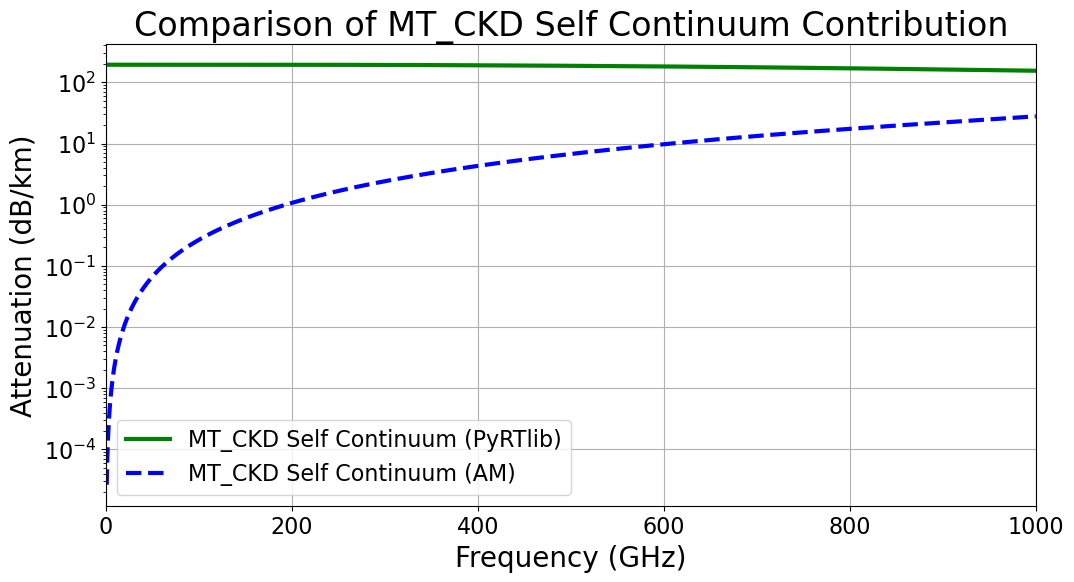

In [38]:
#from Np/km to dB/km
gamma_wet_self_continuum_pyrtlib = alpha_wet_self_continuum_pyrtlib * 4.3429 # in dB/km

#Let's plot the self continuum contribution from PyRTlib against the self continuum contribution from our MT_CKD implementation
plt.figure(figsize=(12, 6))
plt.plot(frequencies * 1e-9, gamma_wet_self_continuum_pyrtlib, label='MT_CKD Self Continuum (PyRTlib)', color='green')
plt.plot(frequencies * 1e-9, gamma_dB_km_self + gamma_dB_km_air, label='MT_CKD Self Continuum (AM)', color='blue', linestyle='dashed')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Attenuation (dB/km)')
plt.title('Comparison of MT_CKD Self Continuum Contribution')
plt.xlim(0, 1000)
plt.yscale('log')
plt.grid()  
plt.legend()
plt.show()